For an ε change (e.g. 1%) in total flux from magnification, what is the change in fiberflux? In other words, if fiberflux changes by fiber_factor*ε, what is multiplicative factor fiber_factor?

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio

from scipy.signal import savgol_filter

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
from scipy import stats
from scipy.interpolate import interp1d

def binned_mean(x, y, bins):
    from scipy import stats
    bin_center, bin_mean = np.full((2, len(bins)-1), np.nan)
    for index in range(len(bins)-1):
        mask = (x>=bins[index]) & (x<bins[index+1])
        if np.sum(mask)>0:
            bin_center[index] = np.mean(x[mask])
            bin_mean[index] = np.mean(y[mask])
    return bin_center, bin_mean

In [4]:
photom_columns = ['MORPHTYPE', 'EBV', 'FLUX_G', 'FLUX_R', 'FLUX_Z', 'FLUX_W1', 'FLUX_W2', 'FIBERFLUX_Z', 'SHAPE_R', 'SERSIC']
more_1_columns = ['SHAPE_E1', 'SHAPE_E2']

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_basic.fits'))
photom = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_photom.fits', columns=photom_columns))
more_1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_south_1.0.0_more_1.fits', columns=more_1_columns))
cat = hstack([cat, photom, more_1], join_type='exact')
print(len(cat))
south = cat.copy()

cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_basic.fits'))
photom = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_photom.fits', columns=photom_columns))
more_1 = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/dr9_lrg_north_1.0.0_more_1.fits', columns=more_1_columns))
cat = hstack([cat, photom, more_1], join_type='exact')
print(len(cat))
north = cat.copy()

cat = vstack([south, north])
print(len(cat))

cat.rename_column('MORPHTYPE', 'TYPE')

9144035
3194955
12338990


In [5]:
maskbits = [1, 8, 9, 11, 12, 13]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))
cat = cat[mask_clean]
print(len(cat))

min_nobs = 2
mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
cat = cat[mask]
print(len(cat))

0.10460434768161737
11048278
10579981


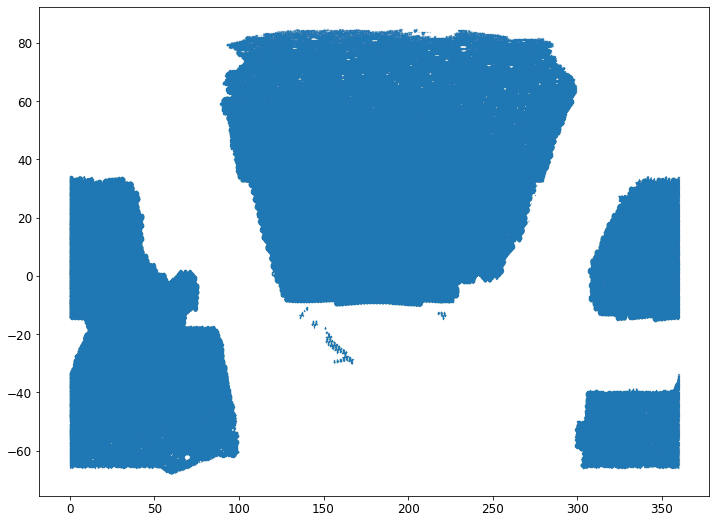

In [6]:
plt.figure(figsize=(12, 9))
plt.plot(cat['RA'], cat['DEC'], '.', ms=0.1)
plt.show()

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [8]:
mask_south = cat['PHOTSYS']=='S'
mask_north = cat['PHOTSYS']=='N'

21.6
21.61


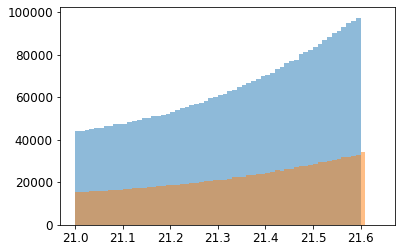

In [9]:
print(np.max(cat['zfibermag'][mask_south]))
print(np.max(cat['zfibermag'][mask_north]))

bins = np.arange(21, 21.65, 0.01)

plt.hist(cat['zfibermag'][mask_south], bins=bins, alpha=0.5)
plt.hist(cat['zfibermag'][mask_north], bins=bins, alpha=0.5)
plt.show()

----------
# REX

In [10]:
mask = cat['TYPE']=='REX'
cat = cat[mask]
print(len(cat))

# r is radius; y is fiberflux fraction
r, y = cat['SHAPE_R'], (cat['FIBERFLUX_Z']/cat['FLUX_Z'])

3077936


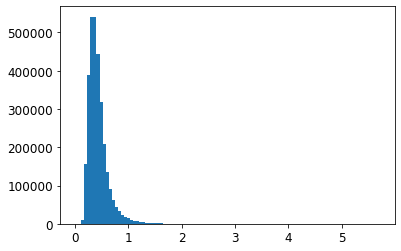

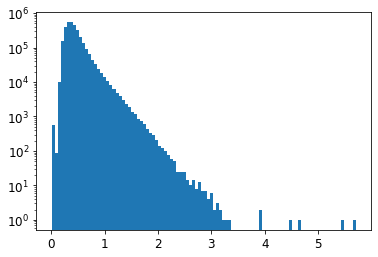

In [11]:
plt.hist(r, 100)
plt.show()

plt.hist(r, 100, log=True)
plt.show()

In [12]:
r_bins = np.arange(0., np.max(r)+1, 0.02)
bin_center, bin_mean = binned_mean(r, y, bins=r_bins)

mask = np.isfinite(bin_mean)
bin_center = bin_center[mask]
bin_mean = bin_mean[mask]

ratio_interp_init = interp1d(bin_center, bin_mean, bounds_error=False, fill_value='extrapolate', kind='quadratic')

In [13]:
r_grid = np.arange(r_bins.min(), r_bins.max()+0.01, 0.01)
ratio_grid = ratio_interp_init(r_grid)

ratio_interp = interp1d(r_grid, ratio_grid, bounds_error=False, fill_value='extrapolate', kind='quadratic')

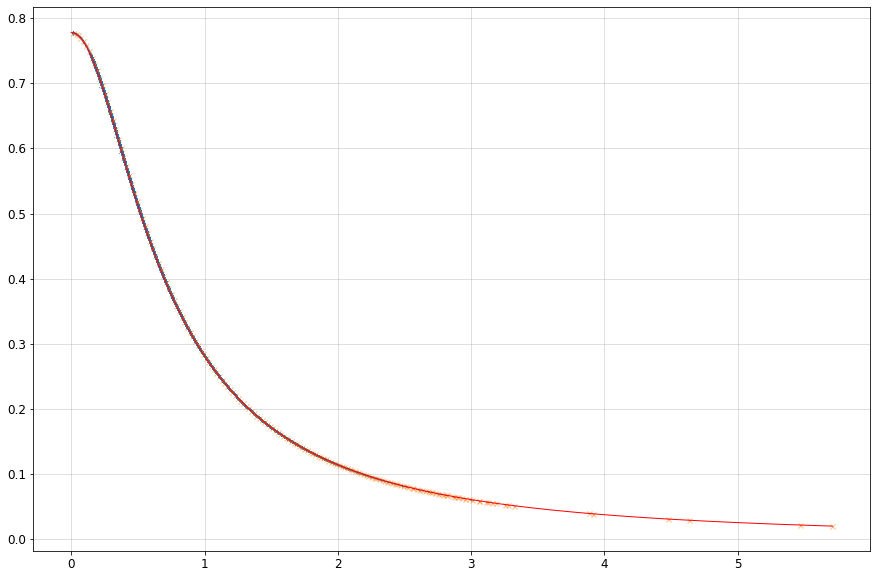

In [14]:
r_plot = np.arange(0., np.max(r)+0.01, 0.01)

plt.figure(figsize=(15, 10))
plt.plot(r, y, '.', ms=0.5)
plt.plot(bin_center, bin_mean, 'x', ms=5, alpha=0.5)
plt.plot(r_plot, ratio_interp(r_plot), lw=1, color='r')
# plt.axis([0, 4, 0., 0.8])
plt.grid(alpha=0.5)
plt.show()

0.004008012016019746


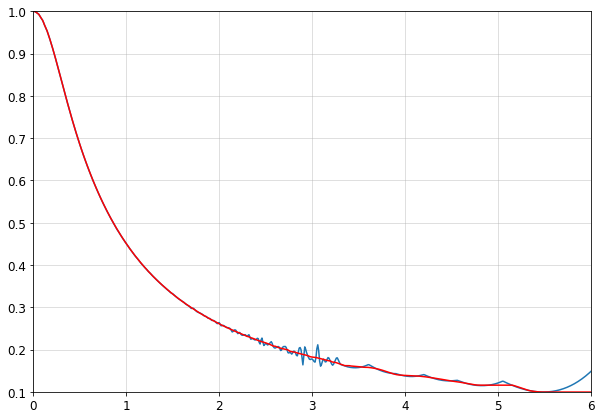

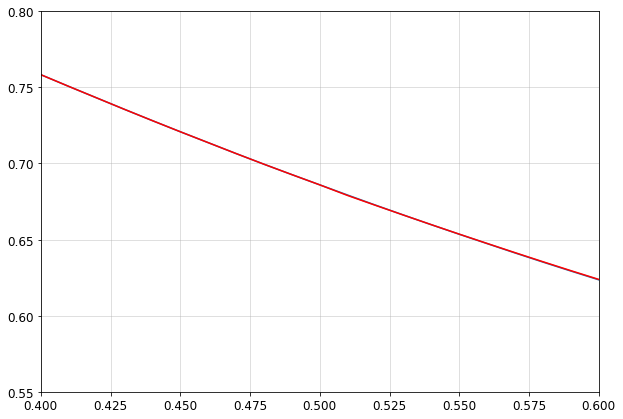

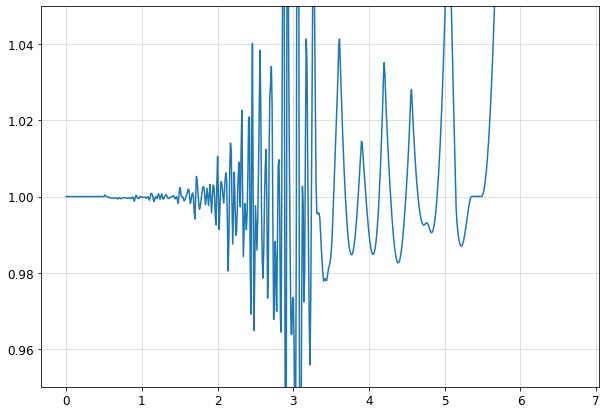

In [21]:
d_radius = 0.001
fplus = ratio_interp(r_grid*(1+d_radius)) * (r_grid*(1+d_radius))**2
fminus = ratio_interp(r_grid*(1-d_radius)) * (r_grid*(1-d_radius))**2
epsilon = (1+d_radius)**2 / (1-d_radius)**2 - 1
print(epsilon)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    f_factor = (fplus/fminus-1) / epsilon
    f_factor[0] = 1.  # fiber factor is unit for point source

mask_filter = r_grid>0.5
fplus_smooth = fplus.copy()
fminus_smooth = fminus.copy()
fplus_smooth[mask_filter] = savgol_filter(fplus, 61, 2)[mask_filter]
fminus_smooth[mask_filter] = savgol_filter(fminus, 61, 2)[mask_filter]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    f_factor_smooth = (fplus_smooth/fminus_smooth-1) / epsilon
    f_factor_smooth[0] = 1.  # fiber factor is unit for point source

if not np.all(np.isfinite(f_factor_smooth)):
    raise ValueError

# Force the fiber factor to be monotonically decreasing with radius
f_factor_smooth = np.minimum.accumulate(f_factor_smooth)

plt.figure(figsize=(10, 7))
plt.plot(r_grid, f_factor)
plt.plot(r_grid, f_factor_smooth, 'r')
plt.axis([0, 6, 0.1, 1])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(r_grid, f_factor)
plt.plot(r_grid, f_factor_smooth, 'r')
plt.axis([0.4, 0.6, 0.55, 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(r_grid, f_factor/f_factor_smooth)
plt.ylim(0.95, 1.05)
plt.grid(alpha=0.5)
plt.show()

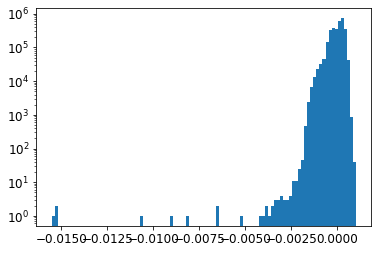

In [22]:
plt.hist(y-ratio_interp(r), 100, log=True);

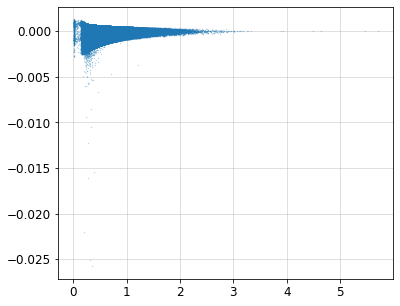

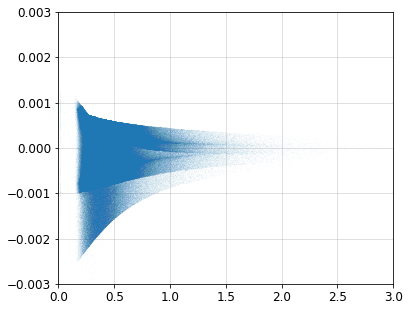

In [23]:
plt.figure(figsize=(6, 5))
plt.plot(r, (y-ratio_interp(r))/y, '.', ms=0.5, alpha=0.5)
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(r, (y-ratio_interp(r))/y, '.', ms=0.1, alpha=0.1)
plt.axis([0, 3, -0.003, 0.003])
plt.grid(alpha=0.5)
plt.show()

In [24]:
np.savez('data/rex.npz', shape_r=r_grid, ratio=ratio_grid, f_factor=f_factor_smooth)

In [25]:
data = np.load('data/rex.npz')
print(data.files)
ratio_interp = interp1d(data['shape_r'], data['ratio'], bounds_error=False, fill_value='extrapolate', kind='quadratic')
f_factor_interp = interp1d(data['shape_r'], data['f_factor'], bounds_error=False, fill_value='extrapolate', kind='quadratic')

['shape_r', 'ratio', 'f_factor']


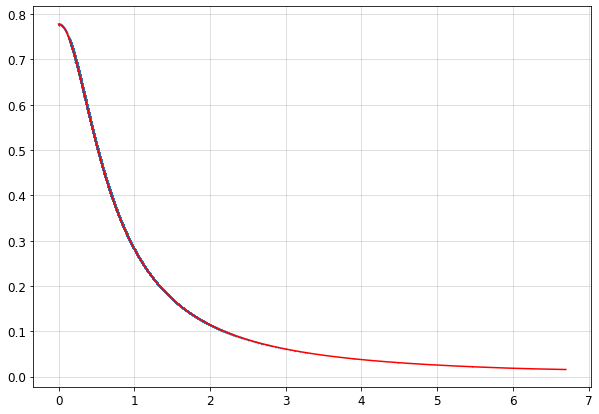

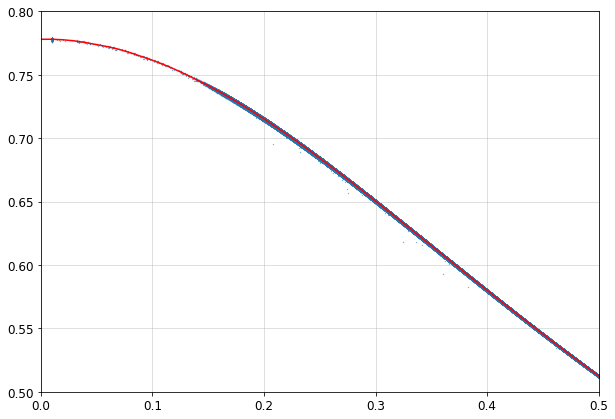

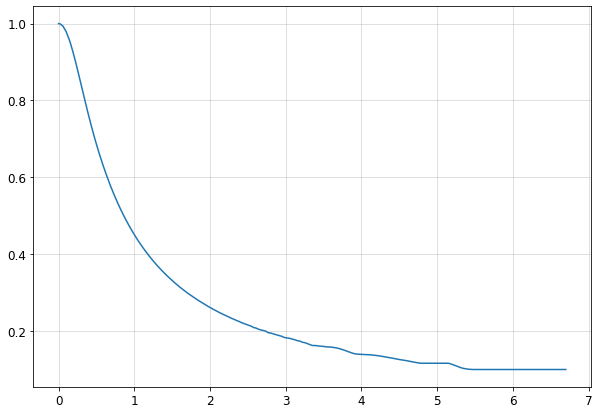

In [26]:
plt.figure(figsize=(10, 7))
plt.plot(r, y, '.', ms=0.5)
plt.plot(r_grid, ratio_interp(r_grid), 'r')
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(r, y, '.', ms=0.5)
plt.plot(r_grid, ratio_interp(r_grid), 'r')
plt.axis([0, 0.5, 0.5, 0.8])
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(r_grid, f_factor_interp(r_grid))
plt.grid(alpha=0.5)
plt.show()